In [5]:
from qiskit import QuantumCircuit
from qiskit.compiler import transpile
from qiskit_aer import AerSimulator
from matplotlib import pyplot as plt
import numpy as np
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
from qiskit.quantum_info import Operator

from tqdm import tqdm

In [6]:
from pmns import PMNS_matrix_4x4
from hamiltonians import U1_omega_Omega, theta_ij, J_ij
from hamiltonians import nunu_interaction_p, nunu_interaction, nunu_interaction_s
from helpers import get_target_state, swap_correction_order_bp, get_interaction_pair_index, count_2q

from backend import get_sampler
from transpile import produce_transpile_args

import sys

sys.path.append('../utils/')

from JobResult import JobResult
from DecoherenceRenormalizer import DecoherenceRenormalizer as DR
from Collector import Collector

In [7]:
QiskitRuntimeService.save_account(
  token="a1a173ef5427a0e110ac33b0fb03add9d211ffae97a6eca6da26474feb765c2b722d2eb2460417c36411e35943f7fe7f2bd1ee2d180cef9d0ee71e180029f770",
  channel="ibm_quantum", # `channel` distinguishes between different account types
  overwrite=True
)

In [8]:
savepath = 'results'
run_name = '4nu_ibm_verify_config_approx995'

SAVEFLAG = True

transpile_config_path = "config/approx995.json"

# backend settings
# aer, sherbrooke, fez, or ibm
sampler, backend, config = get_sampler('ibm')
N = 4

# trotter settings
# set in natural units here
# conversion to mu^-1 happens later automatically
# dt = 5
T_max = 20
steps = 11

# run settings

shots = 4096

transpile_args = produce_transpile_args(config=config, path=transpile_config_path)
print(f"Transpile args: {transpile_args}")

Using IBM Sherbrooke backend
Transpile args: {'optimization_level': 3, 'basis_gates': ['ecr', 'id', 'delay', 'measure', 'reset', 'rz', 'sx', 'x', 'if_else', 'for_loop', 'switch_case'], 'initial_layout': None, 'approximation_degree': 0.995}


In [9]:
#### Defining PMNS matrix and parameters for the Hamiltonian ####
theta_12 = np.radians(33.67)
theta_13 = np.radians(8.58)
theta_23 = np.radians(42.3)
delta_CP = np.radians(232)

U_PMNS_4x4 = PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP)
assert np.allclose(U_PMNS_4x4.conj().T @ U_PMNS_4x4, np.eye(4)), "PMNS matrix is not unitary"

dm21 = 7.41e-5
dm31 = 2.505e-3
E = 1.0

delta_m21 = dm21
delta_m31 = dm31
delta_m32 = delta_m31 - delta_m21
#mu=dm31*N/(2*E) #* 1e-8
mu = dm31 * N / (2 * E)
#omega = np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3) / (4 * E)
omega=dm21 / (2 * E)  
Omega= dm31 / (2 * E)
#B3 = delta_m21 / np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3)
#B8 = (delta_m31 + delta_m32) / (np.sqrt(3) * np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3))
B3=0.025483
B8=0.999567
B = np.zeros(8)
B[2] = B3
B[7] = B8

T_max = T_max / mu
times = np.linspace(0, T_max, steps)

In [10]:
def apply_nunu_interaction(qc, pair_indices, order, base_pattern, dt, interact_func = nunu_interaction, post_fix_func = None):
    """
    interact_func: function for the interaction, for example, nunu_interaction or nunu_interaction_p
    post_fix_func: function to update the order and base_pattern after interaction, given by (order, base_pattern, i, j) -> (new_order, new_base_pattern)
    """
    for i, j in pair_indices:
        q = [2*i, 2*i+1, 2*j, 2*j+1]
        alpha_ij = J_ij(order[i], order[j], E, mu, N) * dt

        interact_func(qc, q, alpha_ij)
        order, base_pattern = post_fix_func(order, base_pattern, i, j) if post_fix_func else (order, base_pattern)
        
    return order, base_pattern


In [11]:
# initialization for run


def init_order_and_base_pattern():
    # generate initial pattern
    base_pattern = []
    for i in range(N):
        if i % 4 == 1:
            base_pattern.append('M')  # nu_mu
        elif i % 4 == 3:
            base_pattern.append('T')  # nu_tau
        else:
            base_pattern.append('E')  # nu_e

    # order map
    order = [i for i in range(N)]

    return order, base_pattern

# interaction sequence
pair_indices = get_interaction_pair_index(N, method ='bubble')

collector = Collector(run_name)


In [ ]:
for t in times:
    collector.add("t", t * mu)

    dt = t
    print("############################################")
    print("Time step:", t)

    order, base_pattern = init_order_and_base_pattern()
    qc = QuantumCircuit(2 * N, 2 * N)

    # Initial state: alternate nu_e, nu_mu, nu_e, nu_tau pattern
    for i in range(N):
        if i % 4 == 1:
            qc.x(2*i + 1)  # nu_mu = |01⟩
        elif i % 4 == 3:
            qc.x(2*i)      # nu_tau = |10⟩

    # Apply U†_PMNS
    Udag = Operator(U_PMNS_4x4.conj().T)
    for i in range(N):
        qc.unitary(Udag, [2*i, 2*i+1], label="U†_PMNS")

    # interaction
    for i in range(N):
        qc.append(U1_omega_Omega(dt, omega, Omega), [2*i, 2*i+1])

    order, base_pattern = apply_nunu_interaction(qc, pair_indices, order, base_pattern, dt,
                                                    interact_func=nunu_interaction_p,
                                                    post_fix_func=swap_correction_order_bp)
    # order, base_pattern = apply_nunu_interaction(qc, pair_indices, order, base_pattern, dt,
    #                                              interact_func=nunu_interaction,
    #                                              post_fix_func=None)

    # Apply U_PMNS
    # U = Operator(U_PMNS_4x4)
    for i in range(N):
        qc.unitary(Udag, [2*i, 2*i+1], label="U†_PMNS").inverse()

    # Measurement
    qc.measure(range(2 * N), reversed((range(2 * N))))

    transpile_args = produce_transpile_args(config=config, path=transpile_config_path)

    tqc = transpile(qc, backend, **transpile_args)

    print("Transpiled circuit has {0} two-qubit gates.".format(count_2q(tqc)))

    dr = DR(tqc, verbose=True)
    print("Identity circuit estimate has {0} two-qubit gates.".format(count_2q(dr.get_identity_circuit())))

    dr.estimate_error_rate(service = sampler, transpile_options = transpile_args)

    print("Estimated error rate:", dr.get_rate_estimate())
    collector.add("error_rate", dr.get_rate_estimate())

    job = JobResult(sampler, verbose=True)

    job.run(tqc, {'shots': shots})

    counts = job.get_counts()

    # Perform physical correction, removing '11' states

    norm = 0

    for key in counts.keys():
        for digi in range(N):
            if key[2*digi] == '1' and key[2*digi+1] == '1':
                counts[key] = 0
                break

    for key in counts.keys():
        norm += counts[key]

    target_state = get_target_state(base_pattern)

    prob = counts.get(target_state, 0) / norm
    # print("Measurement counts:", counts)
    print("Raw probability:", prob)
    prob = dr.renormalize(prob)
    print("Renormalized probability:", prob)
    collector.add("p", prob)
    staterror = np.sqrt(prob * (1 - prob) / norm)
    collector.add("staterror", staterror)

if SAVEFLAG:
    collector.save(path=savepath)



SyntaxError: invalid syntax (3478018980.py, line 87)

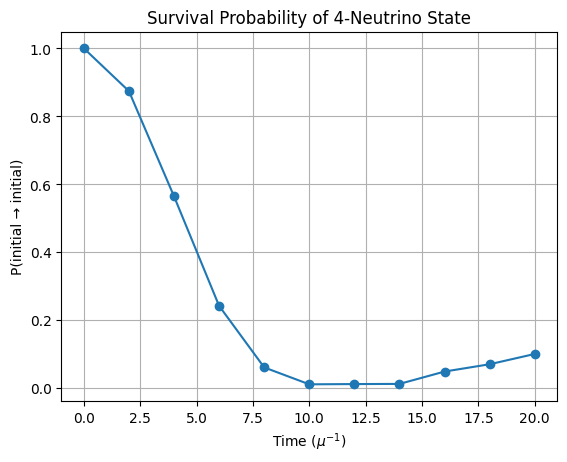

In [ ]:
# Plot
plt.plot(collector.get("t"), collector.get("p"), marker='o')
plt.xlabel(r"Time ($\mu^{-1}$)")
plt.ylabel("P(initial → initial)")
plt.title("Survival Probability of {0}-Neutrino State".format(N))
plt.grid(True)
# plt.savefig(f"{run_name}_survprob.png")

In [ ]:
for j in QiskitRuntimeService().jobs():
    print(j)
    try:
        j.cancel()
    except Exception as e:
        pass

<RuntimeJobV2('d0t2hk6vx7bg0081atd0', 'sampler')>
<RuntimeJobV2('d0t2ga94mb60008xcddg', 'sampler')>
<RuntimeJobV2('d0t2g5rvx7bg0081at8g', 'sampler')>
<RuntimeJobV2('d0t2ex393rd0008nea60', 'sampler')>
<RuntimeJobV2('d0t2cehvx7bg0081asjg', 'sampler')>
<RuntimeJobV2('d0t2bmyvx7bg0081ashg', 'sampler')>
<RuntimeJobV2('d0smxx74mb60008xb210', 'sampler')>
<RuntimeJobV2('d0smxv77qc70008r9at0', 'sampler')>
<RuntimeJobV2('d0smxr71wej00088rgng', 'sampler')>
<RuntimeJobV2('d0smxnyvx7bg00819dq0', 'sampler')>
